### Importing Pkg/Lib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, GridSearchCV

### Download Data from kagglehub and create a master Dataframe

In [ ]:
!install kagglehub
import kagglehub
import pandas as pd
import os

#Takes already splitted train and test DataFrames from the website, combines them,removes duplicates, and returns a single DataFrame.
def getCombinedFishingData(trainDf, testDf):
    combinedDataFrame = pd.concat([trainDf, testDf], ignore_index=True)
    combinedDataFrame = combinedDataFrame.drop_duplicates()
    return combinedDataFrame

# Download the dataSet
path = kagglehub.dataset_download("dataanalystswrs/sri-lankan-offshore-trip-data-202225")

# List to hold all yearly combined data
allYearlyData = []
years = [2022, 2023, 2024, 2025]

#Iterate through each year to load and combine its train/test files
for year in years:
    # Construct folder-specific paths as shown in the Data Explorer
    trainPath = os.path.join(path, "train", f"sri_lanka_fishing_trips_train_{year}.csv")
    testPath = os.path.join(path, "test", f"sri_lanka_fishing_trips_test_{year}.csv")

    trainData = pd.read_csv(trainPath)
    testData = pd.read_csv(testPath)

    # Combine using getCombinedFishingData function
    combinedYearlyDf = getCombinedFishingData(trainData, testData)
    allYearlyData.append(combinedYearlyDf)

    print(f"Year {year}: Processed {len(combinedYearlyDf)} unique records.")

install: missing destination file operand after 'kagglehub'
Try 'install --help' for more information.


100%|██████████| 2.50M/2.50M [00:00<00:00, 228MB/s]

Extracting files...
Year 2022: Processed 5000 unique records.
Year 2023: Processed 5000 unique records.
Year 2024: Processed 5000 unique records.
Year 2025: Processed 5000 unique records.


In [ ]:
# The Master DataFrame
masterFishingData = pd.concat(allYearlyData, ignore_index=True)
masterFishingData = masterFishingData.drop_duplicates()

print(f"Total Combined Records: {len(masterFishingData)}")
masterFishingData.head()

Total Combined Records: 20000


,year,trip_id,vessel_choice,boat_type_or_class,boat_length_ft,engine_hp,port_lat,port_lon,zone_lat,zone_lon,...,license_fee_LKR,total_cost_LKR,revenue_LKR,gross_profit_LKR,trip_type,safety,Yellowfin_Tuna,Skipjack,Marlin,Other
0,2022,1501,type,MTRB,NaN,23,7.209,79.835,8.337538,78.797711,...,50000,163900.36,331135.2,167234.84,deep,safe,88.80,62.42,0.0,177.58
1,2022,2586,type,OFRP,NaN,25,7.209,79.835,7.374164,81.044577,...,50000,169345.23,348343.2,178997.97,deep,safe,107.04,170.90,0.0,0.00
2,2022,2653,type,OFRP,NaN,30,8.550,81.233,8.586807,81.583876,...,50000,151435.07,401580.0,250144.93,deep,safe,188.00,105.50,0.0,0.00
3,2022,1055,class,40_44ft,43.0,156,7.209,79.835,7.263695,79.771001,...,50000,183202.89,394522.2,211319.31,shallow,safe,172.70,85.96,0.0,52.02
4,2022,705,class,above_44,49.0,233,8.550,81.233,8.433261,81.251610,...,50000,379801.72,315723.6,-64078.12,deep,safe,132.68,0.00,0.0,156.56


### Feature Engineering

#### Remove TripID and Change the year variable into TripAge

In [ ]:
# we don't need TripID for our analysis
masterFishingData = masterFishingData.drop(columns=['trip_id'])

# Replace 'year' with 'tripAge'
from datetime import datetime
currentYear = datetime.now().year
masterFishingData['tripAge'] = currentYear - masterFishingData['year']
masterFishingData.drop(columns=['year'], inplace=True)

####  port_lon, port_lan is replaced by fetched the Port location (city)

In [ ]:
!pip install geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

#Fetches only the specific city or town name for each unique set of port coordinates
def getPortCity(df):
    # Initialize Nominatim with a unique user agent
    geolocator = Nominatim(user_agent="sri_lanka_fishing_city_fetcher")
    reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

    # Optimize by processing unique coordinates only
    df['tempCoord'] = list(zip(df['port_lat'], df['port_lon']))
    uniqueCoords = df['tempCoord'].unique()

    cityMapping = {}
    for coord in uniqueCoords:
        try:
            location = reverse(coord, language='en')
            if location and 'address' in location.raw:
                address = location.raw['address']

                # Extract the most relevant city-level name
                cityName = (
                    address.get('city') or
                    address.get('town') or
                    address.get('village') or
                    address.get('suburb') or
                    "Unknown Port"
                )
                cityMapping[coord] = cityName
            else:
                cityMapping[coord] = "Unknown Port"
        except Exception:
            cityMapping[coord] = "API Error"

    # Map the cities back to the dataframe and remove original lat/lon
    df['departurePortLocation'] = df['tempCoord'].map(cityMapping)
    df.drop(columns=['tempCoord', 'port_lat', 'port_lon'], inplace=True)

getPortCity(masterFishingData)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 2.6 MB/s eta 0:00:00


#### Geographic Clustering of fishing zone. Based on the structure of the fishing industry and administrative divisions in Sri Lanka, the fisheries sector is primarily organized around 15 fisheries districts

In [ ]:
!pip install scikit-learn
from sklearn.cluster import KMeans

# n_clusters defines how many distinct fishing zones
# Marine-sector fish production data are collected and analysed on the basis of 15 fisheries districts in SL
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)

# Predict the zone for each coordinate and add as a new column
masterFishingData['fishingZone'] = kmeans.fit_predict(masterFishingData[['zone_lat', 'zone_lon']])
masterFishingData['fishingZone'] = "Zone_" + masterFishingData['fishingZone'].astype(str)
masterFishingData.drop(columns=['zone_lat', 'zone_lon'], inplace=True)


#### Create a accurate fuelCostLKR variable using fuel_liters * fuel_price_per_liter_LKR

In [ ]:
masterFishingData.drop(columns=['fuel_cost_LKR'], inplace=True)

# Create the new variable fuelCostLKR -> fuel_liters * fuel_price_per_liter_LKR
masterFishingData['fuelCostLKR'] = (
    masterFishingData['fuel_liters'] * masterFishingData['fuel_price_per_liter_LKR'])

# Remove the columns used for the calculation
masterFishingData.drop(columns=['fuel_liters', 'fuel_price_per_liter_LKR'], inplace=True)

#### Create a accurate netProfit(LKR) variable using revenue_LKR - total_cost_LKR

In [ ]:
masterFishingData.drop(columns=['gross_profit_LKR'], inplace=True)

# Create the new variable netProfit(LKR)
masterFishingData['netProfit(LKR)'] = (
    masterFishingData['revenue_LKR'] - masterFishingData['total_cost_LKR'])


#### Rename some columns for easier undersdanding

In [ ]:
columnMapping = {
    'trip_hours': 'totalHoursSpent(travelAndfishing)',
    'no_days': 'allowedOffshoreDays',
    'month': 'MonthOfDeparture',
    'precip_mm': 'estimatedRainfall(mm)',
    'visibility_km': 'visibilityDistance(km)',
    'safety': 'safetyCategory',
    'Yellowfin_Tuna': 'catchWeightOfYellowfinTuna(kg)',
    'Skipjack': 'catchWeightOfSkipjack(kg)',
    'Marlin': 'catchWeightOfMarlin(kg)',
    'Other': 'catchWeightOfOtherFish(kg)'
}

masterFishingData.rename(columns=columnMapping, inplace=True)

### Overlook on the Data

In [ ]:
masterFishingData.shape

(20000, 34)

In [ ]:
# check duplicated rows
masterFishingData.duplicated().value_counts()

,count
False,20000


In [ ]:
masterFishingData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   vessel_choice                      20000 non-null  object 
 1   boat_type_or_class                 20000 non-null  object 
 2   boat_length_ft                     10118 non-null  float64
 3   engine_hp                          20000 non-null  int64  
 4   distance_km                        20000 non-null  float64
 5   totalHoursSpent(travelAndfishing)  20000 non-null  float64
 6   allowedOffshoreDays                20000 non-null  int64  
 7   crew_size                          20000 non-null  int64  
 8   MonthOfDeparture                   20000 non-null  int64  
 9   wind_kph                           20000 non-null  float64
 10  wave_m                             20000 non-null  float64
 11  estimatedRainfall(mm)              20000 non-null  flo

In [ ]:
# to describe a numircal columns
masterFishingData.describe()

,boat_length_ft,engine_hp,distance_km,totalHoursSpent(travelAndfishing),allowedOffshoreDays,crew_size,MonthOfDeparture,wind_kph,wave_m,estimatedRainfall(mm),...,license_fee_LKR,total_cost_LKR,revenue_LKR,catchWeightOfYellowfinTuna(kg),catchWeightOfSkipjack(kg),catchWeightOfMarlin(kg),catchWeightOfOtherFish(kg),tripAge,fuelCostLKR,netProfit(LKR)
count,10118.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.0,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04
mean,40.057225,117.370600,48.788212,24.292978,2.503550,5.57045,6.511350,19.644461,1.285006,3.186043,...,50000.0,3.441063e+05,308987.730945,90.172297,74.743664,54.730134,29.640265,2.500000,1.340997e+05,-3.511857e+04
std,7.296607,73.895797,45.217382,44.965358,3.387515,2.59258,3.452516,10.377488,0.538020,3.228370,...,0.0,4.885460e+05,131039.370212,67.243049,69.968963,68.018838,57.020324,1.118062,3.069376e+05,5.055847e+05
min,28.000000,1.000000,0.003147,8.000000,1.000000,1.00000,1.000000,3.000000,0.100000,0.000033,...,50000.0,7.598698e+04,36007.200000,0.000000,0.000000,0.000000,0.000000,1.000000,8.616685e+02,-4.455159e+06
25%,34.000000,34.000000,14.261059,8.000000,1.000000,4.00000,4.000000,11.948988,0.912162,0.927966,...,50000.0,1.417510e+05,211690.800000,0.000000,0.000000,0.000000,0.000000,1.750000,1.933610e+04,-4.070151e+04
50%,40.000000,119.000000,34.509886,8.000000,1.000000,5.00000,7.000000,19.179661,1.275474,2.182437,...,50000.0,1.718527e+05,301756.050000,96.250000,74.180000,0.000000,0.000000,2.500000,3.345731e+04,9.637186e+04
75%,45.000000,169.000000,69.558208,13.621193,2.000000,7.00000,10.000000,26.506766,1.640697,4.380424,...,50000.0,2.367899e+05,398213.550000,147.850000,137.410000,113.997500,0.000000,3.250000,6.956527e+04,2.108651e+05
max,55.000000,345.000000,180.477473,490.149153,15.000000,12.00000,12.000000,67.244175,3.984497,38.144889,...,50000.0,4.679731e+06,830961.900000,199.960000,199.990000,199.980000,200.000000,4.000000,3.850516e+06,6.708708e+05


### Splitting data

In [ ]:
from sklearn.model_selection import train_test_split

trainSet, testSet = train_test_split(masterFishingData, test_size=0.2, random_state=42)

print(f"Training set shape: {trainSet.shape}")
print(f"Testing set shape: {testSet.shape}")

Training set shape: (16000, 34)
Testing set shape: (4000, 34)


### Cleaning data

In [ ]:
# check null values
print(str(trainSet.isnull().sum().sort_values(ascending=True)),"\n")
print("Missing percentages\n")
print(str(trainSet.isnull().mean().mul(100).round(2).sort_values(ascending=True)),"\n")

columnsWithNull = trainSet.columns[trainSet.isnull().any()].tolist()
print("columnsWithNull: ",columnsWithNull,"\n")


vessel_choice                           0
boat_type_or_class                      0
engine_hp                               0
distance_km                             0
allowedOffshoreDays                     0
totalHoursSpent(travelAndfishing)       0
crew_size                               0
MonthOfDeparture                        0
visibilityDistance(km)                  0
wind_kph                                0
wave_m                                  0
estimatedRainfall(mm)                   0
ice_cost_LKR                            0
departure_hour                          0
food_cost_LKR                           0
medicine_cost_LKR                       0
safetyCategory                          0
gear_cost_LKR                           0
crew_wage_LKR                           0
variable_cost_LKR                       0
license_fee_LKR                         0
total_cost_LKR                          0
revenue_LKR                             0
trip_type                         

#### We use MICE Algorithm to impute boat_length_ft missing values

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def performMiceImputation(df, colWithNull):
    df = df.copy()
    numericalFeatures = [
        'engine_hp', 'distance_km', 'totalHoursSpent(travelAndfishing)',
        'allowedOffshoreDays', 'crew_size', 'wind_kph', 'wave_m',
        'estimatedRainfall(mm)', 'visibilityDistance(km)', 'ice_cost_LKR',
        'food_cost_LKR', 'medicine_cost_LKR', 'gear_cost_LKR', 'crew_wage_LKR',
        'variable_cost_LKR', 'license_fee_LKR', 'total_cost_LKR', 'revenue_LKR',
        'catchWeightOfYellowfinTuna(kg)', 'catchWeightOfSkipjack(kg)',
        'catchWeightOfMarlin(kg)', 'catchWeightOfOtherFish(kg)', 'tripAge',
        'fuelCostLKR', 'netProfit(LKR)']

    # Prepare the data matrix (impute target + context features)
    dataToImpute = df[[colWithNull] + numericalFeatures]

    imputer = IterativeImputer(max_iter=10, random_state=42, min_value=0)
    imputedMatrix = imputer.fit_transform(dataToImpute)
    df[colWithNull] = imputedMatrix[:, 0]
    return df

In [ ]:
trainSetCopy = trainSet.copy()
testSetCopy = testSet.copy()

for col in columnsWithNull:
    testSetCopy = performMiceImputation(testSetCopy, col)
    trainSetCopy = performMiceImputation(trainSetCopy, col)

#Verify Test Set is clean
print("Train Set Null Values:")
print(str(trainSetCopy.isnull().sum().sum()))
print("\nTest Set Null Values:")
print(str(testSetCopy.isnull().sum().sum()))


Train Set Null Values:
0

Test Set Null Values:
0


In [ ]:
trainSetCopy.trip_type.value_counts()

,count
trip_type,
deep,13047
shallow,2953


### Modelling

####Categorical and numerical values

In [ ]:
categColNames = masterFishingData.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()
print("Categorical: ",str(categColNames),"\n", len(categColNames),"\n")

numericColNames = masterFishingData.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical: ",str(numericColNames),"\n", len(numericColNames))


Categorical:  ['vessel_choice', 'boat_type_or_class', 'trip_type', 'safetyCategory', 'departurePortLocation', 'fishingZone'] 
 6 

Numerical:  ['boat_length_ft', 'engine_hp', 'distance_km', 'totalHoursSpent(travelAndfishing)', 'allowedOffshoreDays', 'crew_size', 'MonthOfDeparture', 'wind_kph', 'wave_m', 'estimatedRainfall(mm)', 'visibilityDistance(km)', 'departure_hour', 'ice_cost_LKR', 'food_cost_LKR', 'medicine_cost_LKR', 'gear_cost_LKR', 'crew_wage_LKR', 'variable_cost_LKR', 'license_fee_LKR', 'total_cost_LKR', 'revenue_LKR', 'catchWeightOfYellowfinTuna(kg)', 'catchWeightOfSkipjack(kg)', 'catchWeightOfMarlin(kg)', 'catchWeightOfOtherFish(kg)', 'tripAge', 'fuelCostLKR', 'netProfit(LKR)'] 
 28


In [ ]:
yTrainObj1 = trainSetCopy.copy()['total_cost_LKR']
yTestObj1 = testSetCopy.copy()['total_cost_LKR']
xTrainObj1 = trainSetCopy.copy().drop('total_cost_LKR', axis=1)
xTestObj1 = testSetCopy.copy().drop('total_cost_LKR', axis=1)

print(yTrainObj1.shape)
print(yTestObj1.shape)
print(xTrainObj1.shape)
print(xTestObj1.shape)


(16000,)
(4000,)
(16000, 33)
(4000, 33)


##New Variable creation (Sea condition)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the Feature Engineering Function
def create_sea_condition(df):
    """
    Categorizes sea conditions based on wave height and wind speed.
    Logic: Rough (Waves > 2m OR Wind > 30kph),
           Moderate (Waves 1-2m OR Wind 15-30kph),
           else Calm.
    """
    conditions = [
        (df['wave_m'] > 2.0) | (df['wind_kph'] > 30),
        (df['wave_m'] > 1.0) | (df['wind_kph'] > 15)
    ]
    choices = ['Rough', 'Moderate']
    df['seaCondition'] = np.select(conditions, choices, default='Calm')
    return df

# 2. Apply the transformation to your split objects
xTrainObj1 = create_sea_condition(xTrainObj1)
xTestObj1 = create_sea_condition(xTestObj1)



In [ ]:
xTrainObj1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 5894 to 15795
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   vessel_choice                      16000 non-null  object 
 1   boat_type_or_class                 16000 non-null  object 
 2   boat_length_ft                     16000 non-null  float64
 3   engine_hp                          16000 non-null  int64  
 4   distance_km                        16000 non-null  float64
 5   totalHoursSpent(travelAndfishing)  16000 non-null  float64
 6   allowedOffshoreDays                16000 non-null  int64  
 7   crew_size                          16000 non-null  int64  
 8   MonthOfDeparture                   16000 non-null  int64  
 9   wind_kph                           16000 non-null  float64
 10  wave_m                             16000 non-null  float64
 11  estimatedRainfall(mm)              16000 non-null  float

####Log transformed

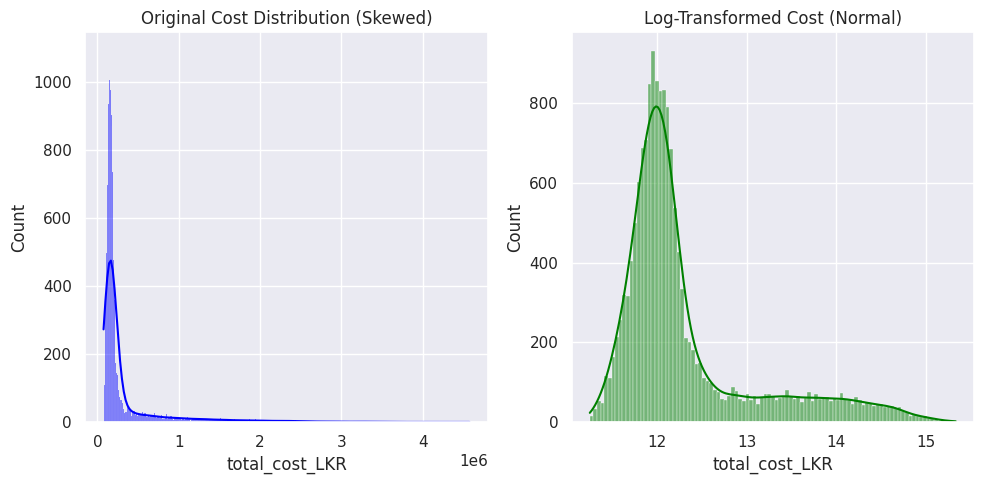

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply Log Transformation
# We use log1p (log 1 + x) to handle potential zero values safely
yTrainLog = np.log1p(yTrainObj1)
yTestLog = np.log1p(yTestObj1)

# 2. Visualize the New Distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(yTrainObj1, kde=True, color='blue')
plt.title("Original Cost Distribution (Skewed)")

plt.subplot(1, 2, 2)
sns.histplot(yTrainLog, kde=True, color='green')
plt.title("Log-Transformed Cost (Normal)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_4469/3751081548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


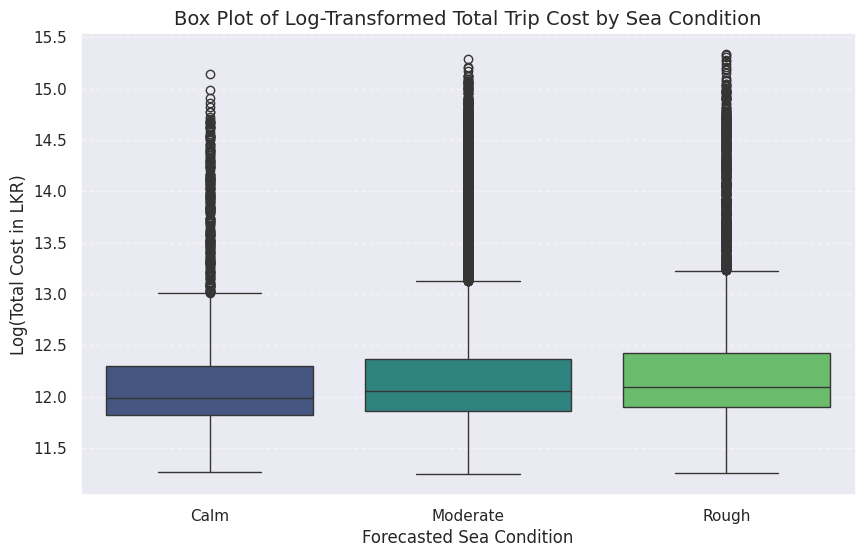

In [ ]:
# 1. Apply Log Transformation to the target variable
yTrainLog = np.log1p(yTrainObj1)

# 2. Create a temporary DataFrame for plotting
# xTrainObj1 already has the 'seaCondition' column from the previous step
plot_df = xTrainObj1.copy()
plot_df['log_total_cost'] = yTrainLog

# 3. Generate the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='seaCondition',
    y='log_total_cost',
    data=plot_df,
    palette='viridis',
    order=['Calm', 'Moderate', 'Rough']
)

# 4. Add formatting and labels
plt.title("Box Plot of Log-Transformed Total Trip Cost by Sea Condition", fontsize=14)
plt.ylabel("Log(Total Cost in LKR)", fontsize=12)
plt.xlabel("Forecasted Sea Condition", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

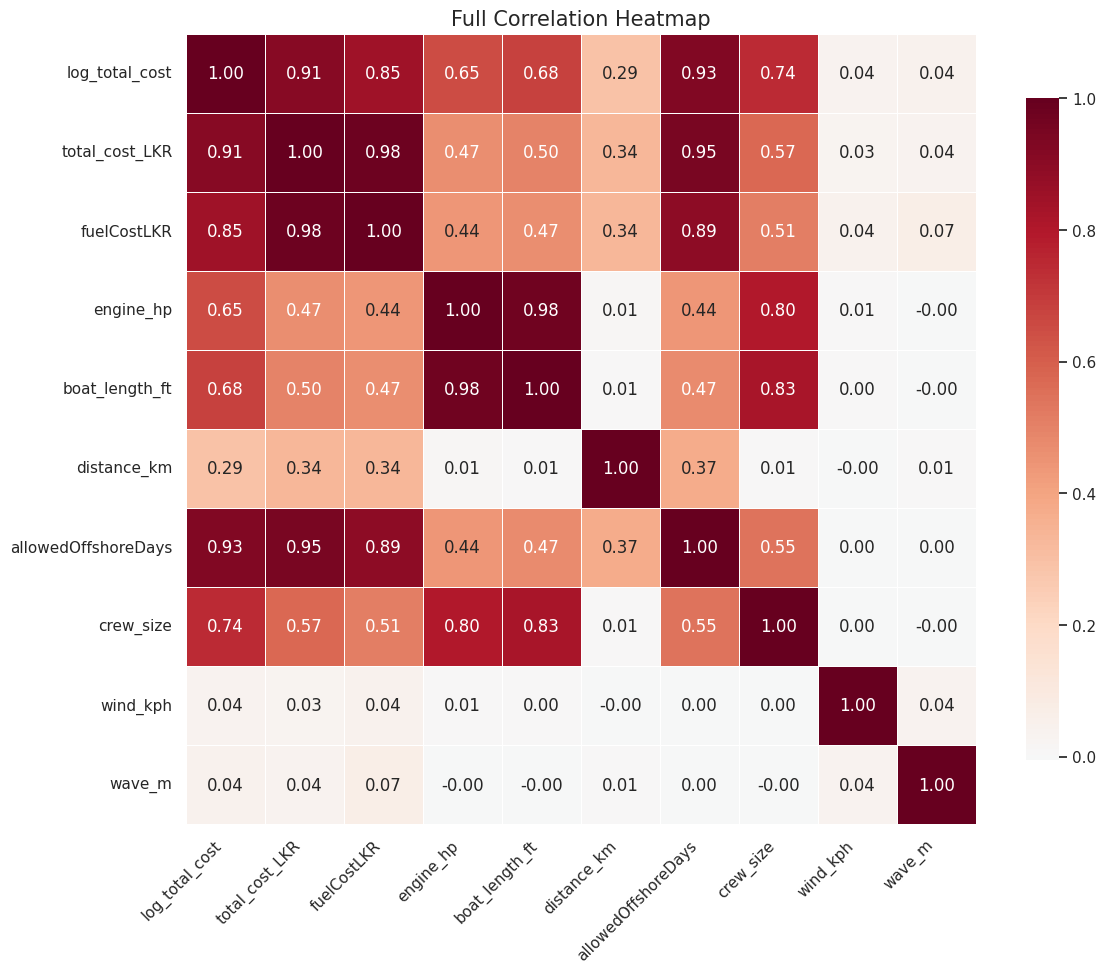

In [ ]:
# 1. Prepare your plotting dataframe
# Use trainSetCopy to ensure all columns (features and target) are present
heatmap_df = trainSetCopy.copy()

# 2. Add the log-transformed column
heatmap_df['log_total_cost'] = np.log1p(heatmap_df['total_cost_LKR'])

# 3. Select all relevant numeric columns for the research
# This fills the "spaces" by including more variables and showing the full square
cols_to_plot = [
    'log_total_cost', 'total_cost_LKR', 'fuelCostLKR',
    'engine_hp', 'boat_length_ft', 'distance_km',
    'allowedOffshoreDays', 'crew_size', 'wind_kph', 'wave_m'
]

# 4. Calculate the correlation matrix
full_corr = heatmap_df[cols_to_plot].corr()

# 5. Generate the FULL square heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    full_corr,
    annot=True,       # Show correlation values
    fmt=".2f",        # 2 decimal places
    cmap='RdBu_r',    # Red-to-Blue diverging color map
    center=0,         # White color represents zero correlation
    square=True,      # Keep cells as squares
    linewidths=.5,    # Add small lines between cells
    cbar_kws={"shrink": .8} # Slightly smaller color bar for better fit
)

plt.title("Full Correlation Heatmap", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


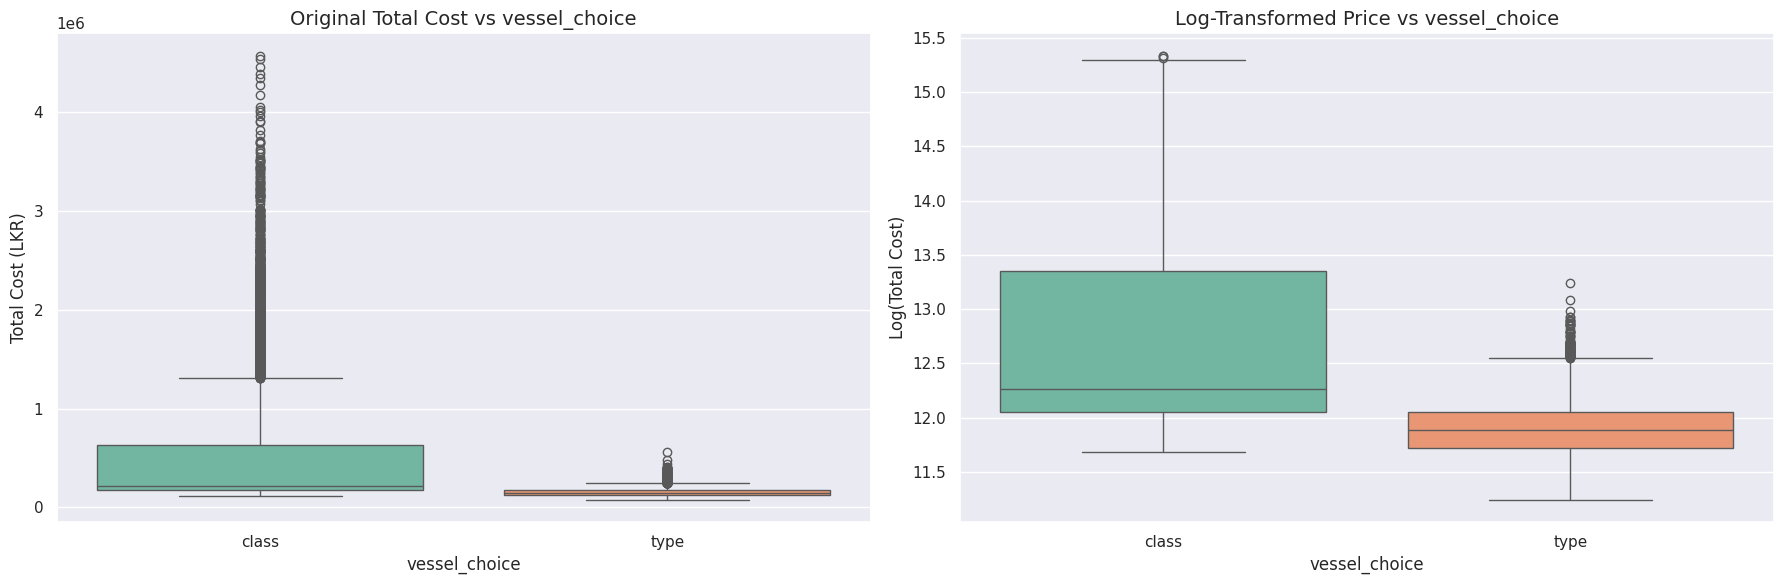

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


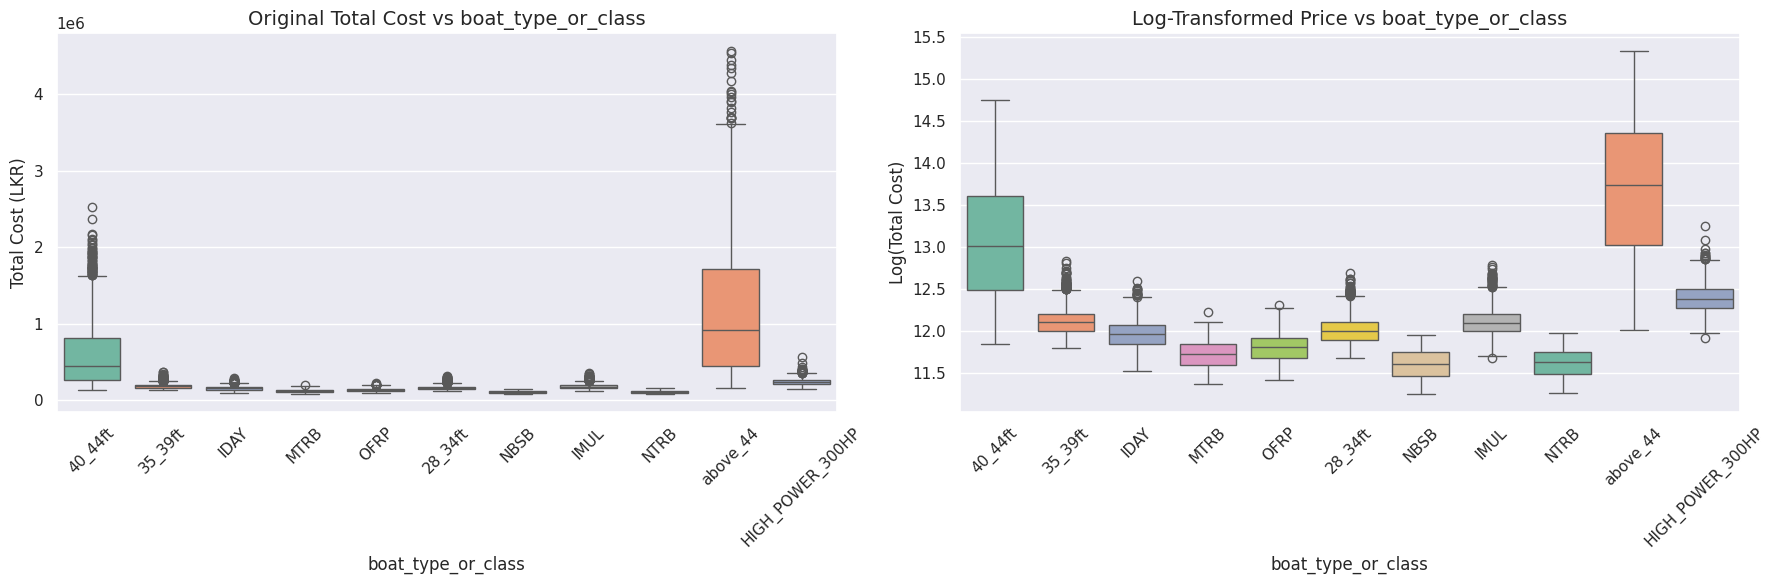

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


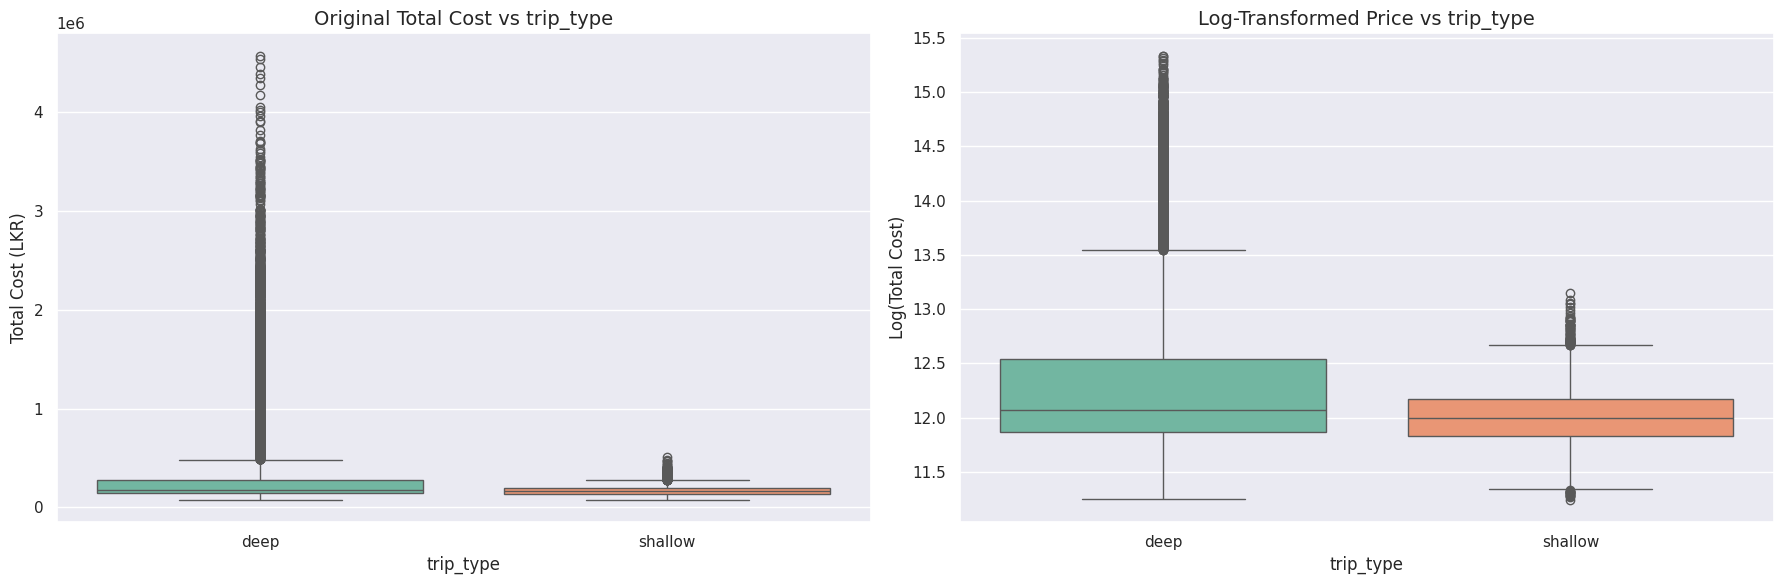

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


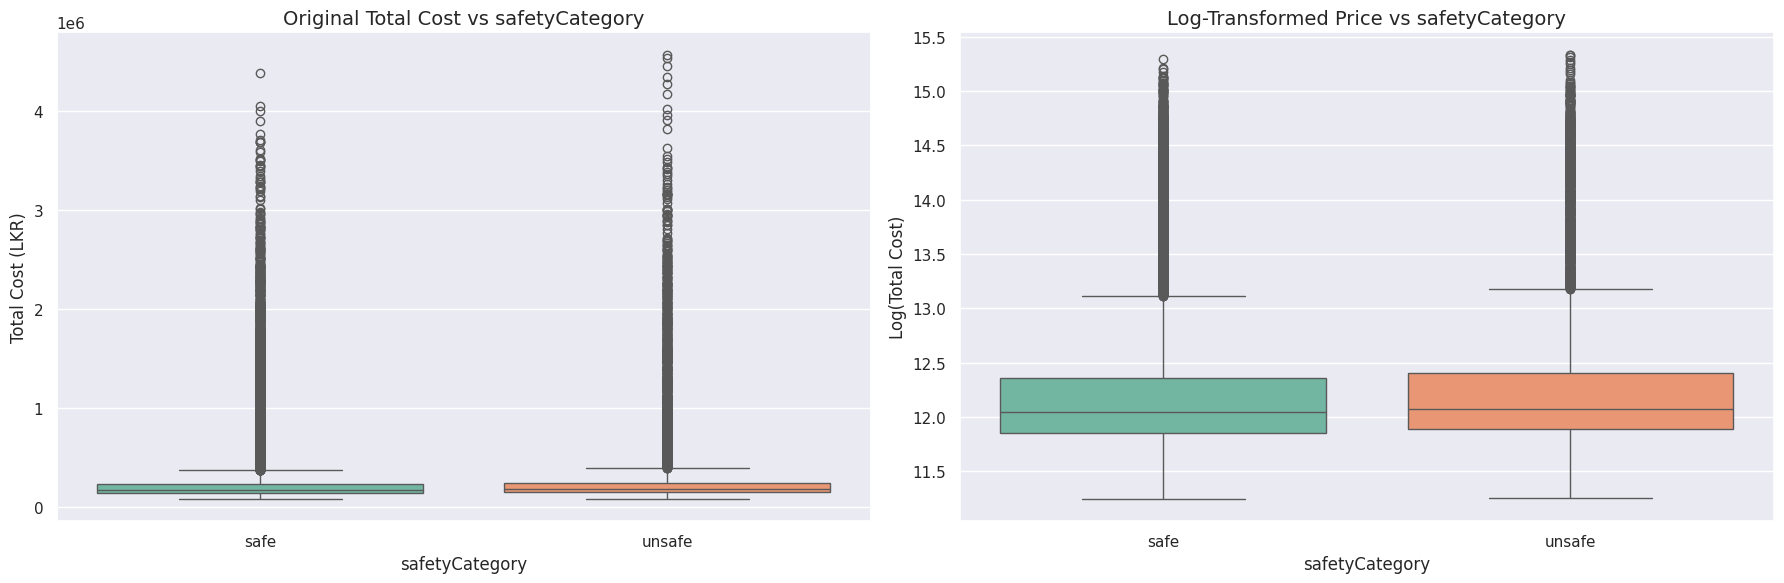

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


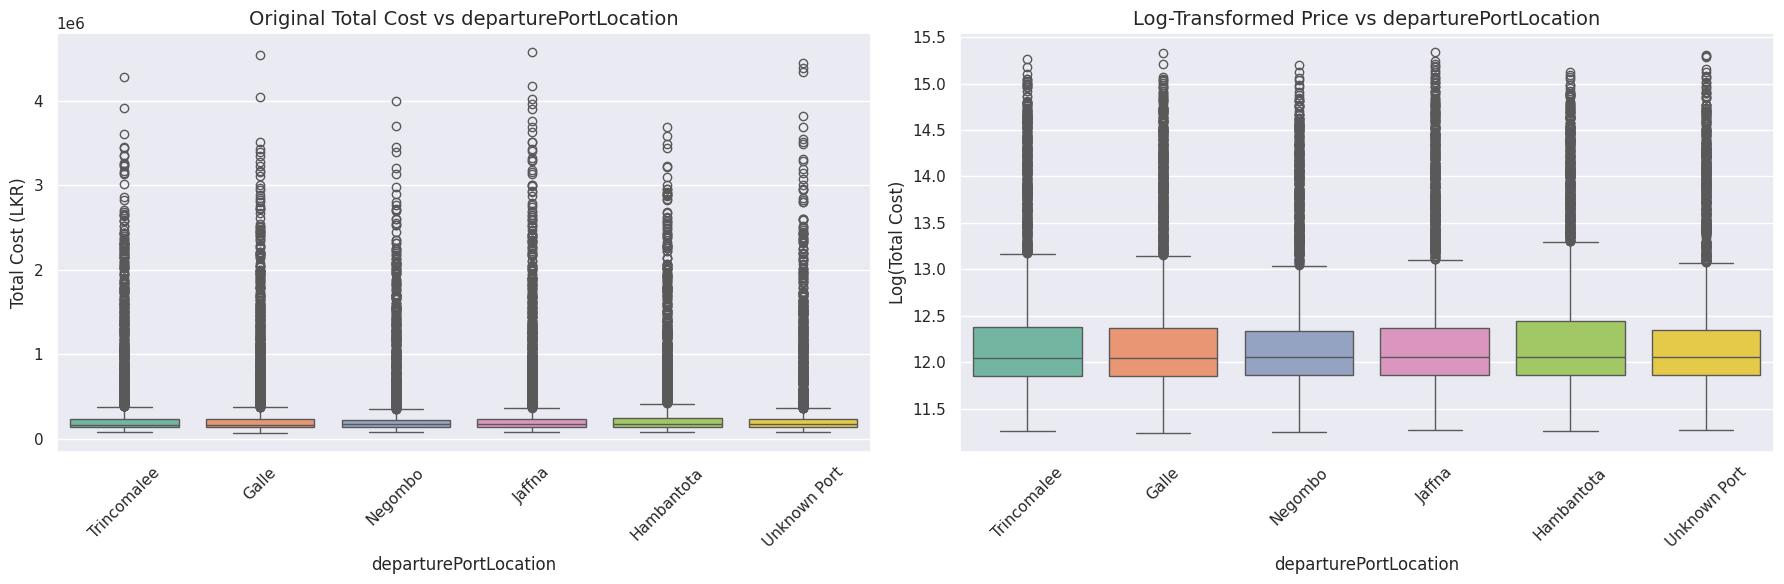

/tmp/ipykernel_4469/3882578437.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_4469/3882578437.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')


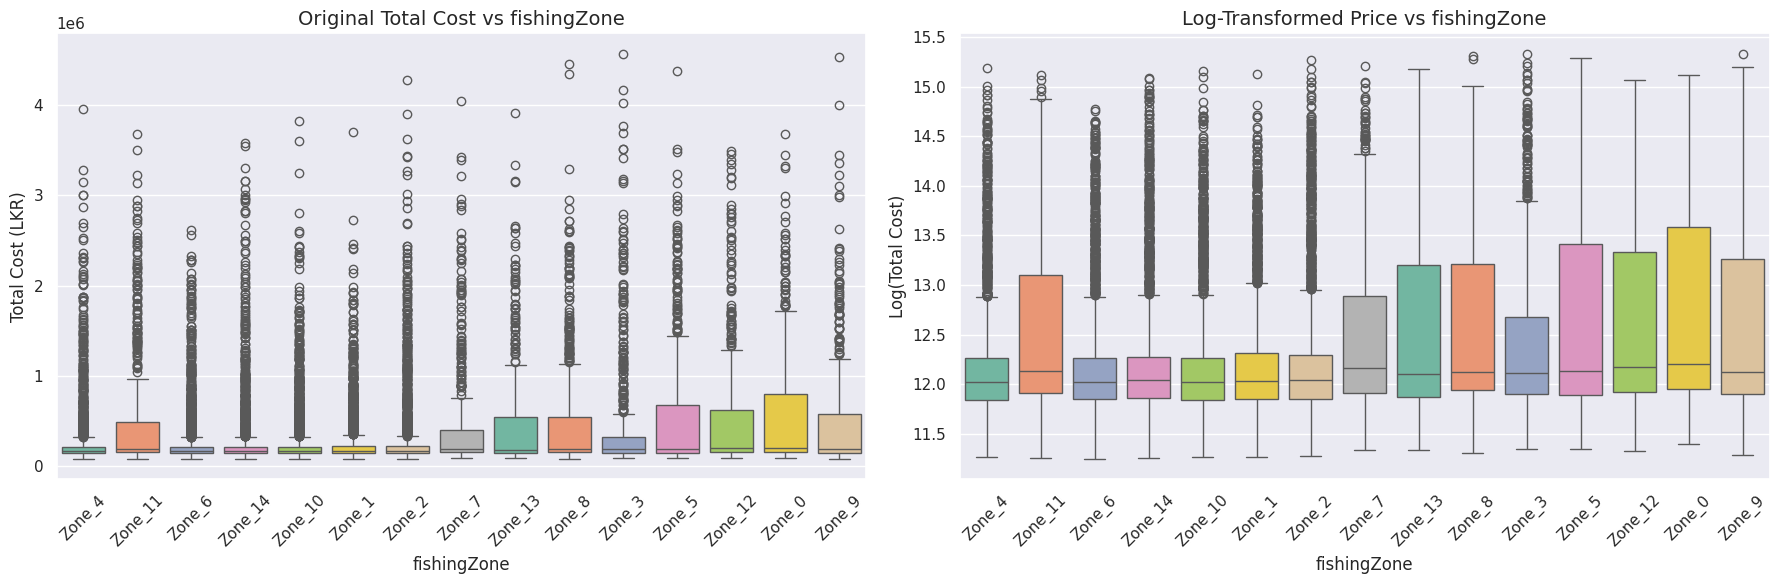

In [ ]:
# We use trainSetCopy as it contains both the categories and the target
plot_df = trainSetCopy.copy()
plot_df['log_total_cost'] = np.log1p(plot_df['total_cost_LKR'])

# 2. Define the categorical columns to visualize
categorical_vars = [
    'vessel_choice',
    'boat_type_or_class',
    'trip_type',
    'safetyCategory',
    'departurePortLocation',
    'fishingZone'
]

# 3. Loop through each variable and create side-by-side comparison plots
# This clearly shows why the log transformation is necessary for your "Advanced Analysis"
for var in categorical_vars:
    # Create a new figure for each variable with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Original Price (Skewed)
    sns.boxplot(x=var, y='total_cost_LKR', data=plot_df, ax=axes[0], palette='Set2')
    axes[0].set_title(f'Original Total Cost vs {var}', fontsize=14)
    axes[0].set_ylabel('Total Cost (LKR)')

    # Plot 2: Log Transformed Price (Normalized)
    sns.boxplot(x=var, y='log_total_cost', data=plot_df, ax=axes[1], palette='Set2')
    axes[1].set_title(f'Log-Transformed Price vs {var}', fontsize=14)
    axes[1].set_ylabel('Log(Total Cost)')

    # Rotate labels if there are many categories
    if plot_df[var].nunique() > 3:
        axes[0].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4469/3822153261.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4469/3822153261.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


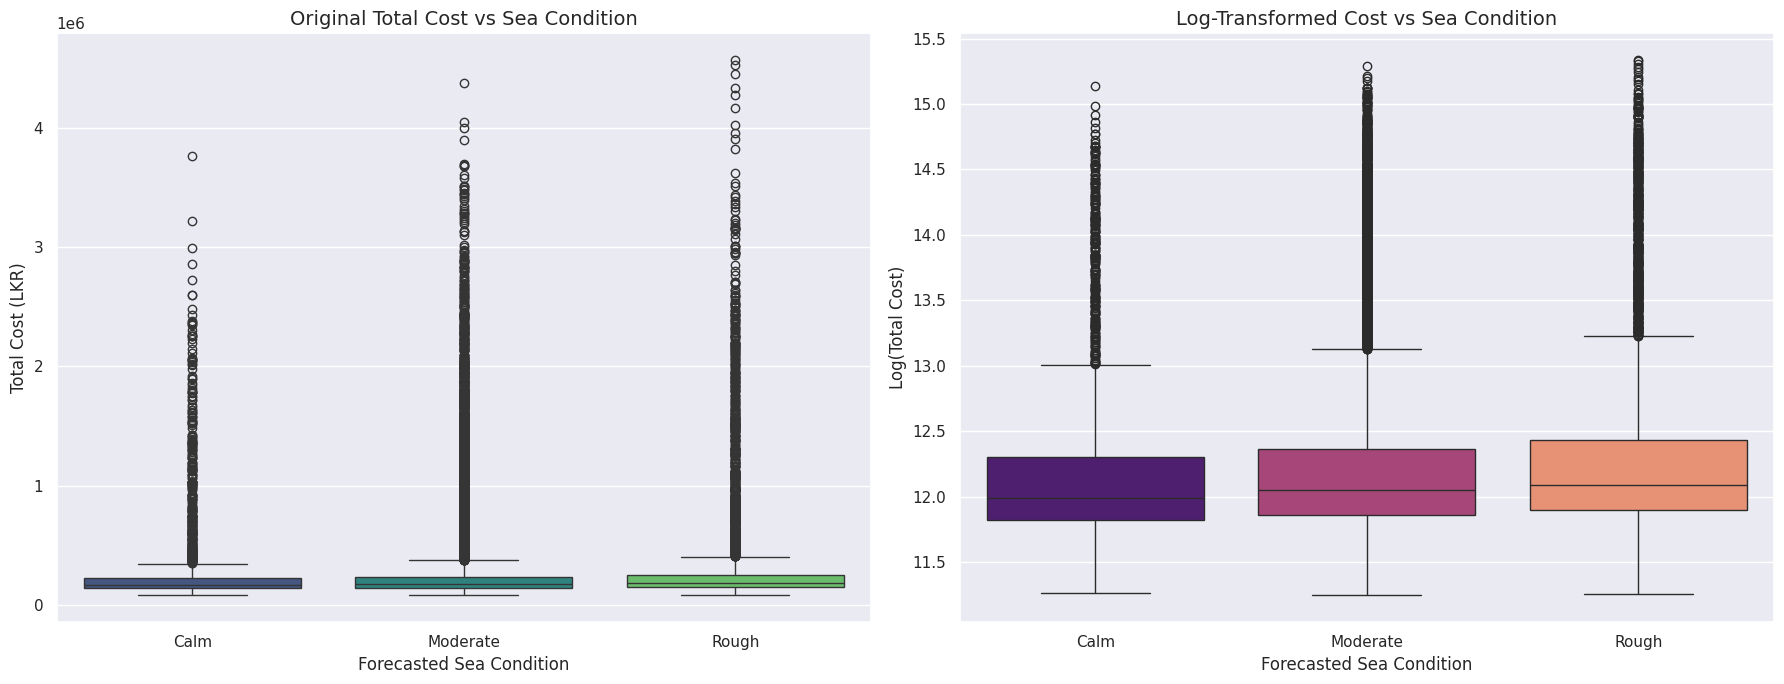

In [ ]:
# 1. Create a temporary plotting dataframe
# This combines the 'seaCondition' from xTrainObj1 and the price from yTrainObj1
plot_df = pd.DataFrame({
    'seaCondition': xTrainObj1['seaCondition'],
    'total_cost_LKR': yTrainObj1,
    'log_total_cost': np.log1p(yTrainObj1)
})

# 2. Create the Figure with side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Original Total Cost
sns.boxplot(
    x='seaCondition',
    y='total_cost_LKR',
    data=plot_df,
    ax=axes[0],
    palette='viridis',
    order=['Calm', 'Moderate', 'Rough']
)
axes[0].set_title("Original Total Cost vs Sea Condition", fontsize=14)
axes[0].set_ylabel("Total Cost (LKR)")
axes[0].set_xlabel("Forecasted Sea Condition")

# Plot B: Log-Transformed Cost
sns.boxplot(
    x='seaCondition',
    y='log_total_cost',
    data=plot_df,
    ax=axes[1],
    palette='magma',
    order=['Calm', 'Moderate', 'Rough']
)
axes[1].set_title("Log-Transformed Cost vs Sea Condition", fontsize=14)
axes[1].set_ylabel("Log(Total Cost)")
axes[1].set_xlabel("Forecasted Sea Condition")

plt.tight_layout()
plt.show()

/tmp/ipykernel_4469/2932204869.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_results.values, y=mi_results.index, palette='magma')


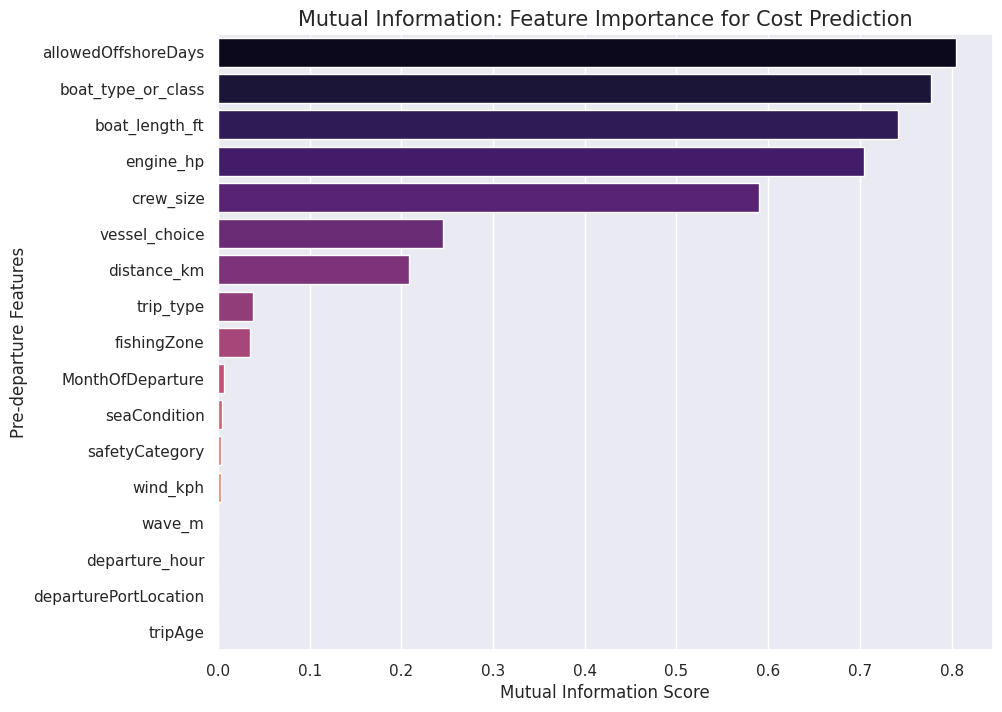

Top Predictors identified by Mutual Information:
allowedOffshoreDays      0.804800
boat_type_or_class       0.777715
boat_length_ft           0.741430
engine_hp                0.704986
crew_size                0.589596
vessel_choice            0.245836
distance_km              0.208121
trip_type                0.038261
fishingZone              0.034970
MonthOfDeparture         0.006461
seaCondition             0.004255
safetyCategory           0.003295
wind_kph                 0.002988
wave_m                   0.000379
departure_hour           0.000000
departurePortLocation    0.000000
tripAge                  0.000000
Name: MI Scores, dtype: float64


In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# 1. Select only the "Wanted" pre-departure features
wanted_features = [
    'vessel_choice', 'boat_type_or_class', 'boat_length_ft', 'engine_hp',
    'distance_km', 'allowedOffshoreDays', 'crew_size', 'wind_kph',
    'wave_m', 'departurePortLocation','departure_hour', 'fishingZone', 'trip_type', 'safetyCategory', 'seaCondition','MonthOfDeparture','tripAge',
]

# 2. Prepare the feature matrix (X) and target (y)
X_mi = xTrainObj1[wanted_features].copy()
y_mi = yTrainObj1 # You can also use yTrainLog here

# 3. Label encode categorical columns (MI requires numerical input)
categorical_cols = X_mi.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col])

# 4. Calculate Mutual Information scores
# discrete_features: True for categorical/integer, False for continuous
# For simplicity, we let sklearn auto-detect, or you can specify.
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)

# 5. Organize and Visualize
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_results.values, y=mi_results.index, palette='magma')
plt.title("Mutual Information: Feature Importance for Cost Prediction", fontsize=15)
plt.xlabel("Mutual Information Score")
plt.ylabel("Pre-departure Features")
plt.show()

print("Top Predictors identified by Mutual Information:")
print(mi_results)

/tmp/ipykernel_4469/2593445352.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='MonthOfDeparture', data=trainSetCopy, palette='viridis', ax=ax1)


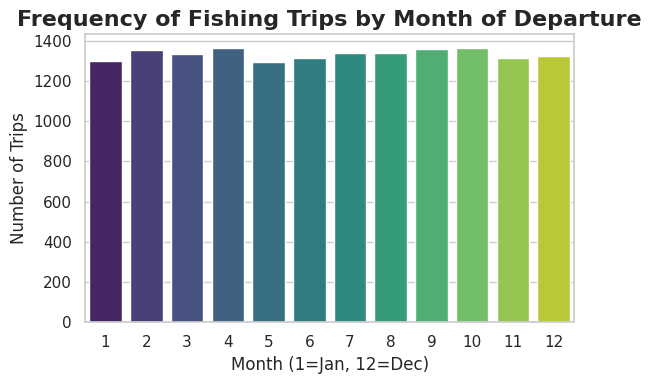

<Figure size 640x480 with 0 Axes>

In [ ]:
# Set standard professional theme
sns.set_theme(style="whitegrid")

# 1. Frequency Bar Chart (Trip Volume)
fig1, ax1 = plt.subplots(figsize=(6, 4))
sns.countplot(x='MonthOfDeparture', data=trainSetCopy, palette='viridis', ax=ax1)
ax1.set_title('Frequency of Fishing Trips by Month of Departure', fontsize=16, fontweight='bold')
ax1.set_xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
ax1.set_ylabel('Number of Trips', fontsize=12)
plt.tight_layout()
plt.savefig('report_month_frequency.png', dpi=300)
plt.show()




plt.tight_layout()
plt.savefig('report_month_cost.png', dpi=300) # High-resolution output
plt.show()

##Statistical test

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
!pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select specific numerical features
# (Including too many at once makes it slow; start with these core ones)
numerical_cols = [
    'boat_length_ft', 'engine_hp', 'distance_km', 'crew_size',
    'allowedOffshoreDays', 'wind_kph', 'wave_m'
]

# 2. Prepare data: Drop NaNs and take a sample (e.g., 5000 rows)
# Sampling prevents the KeyboardInterrupt/Hang
vif_temp = xTrainObj1[numerical_cols].dropna()
if len(vif_temp) > 5000:
    vif_temp = vif_temp.sample(5000, random_state=42)

# 3. Add a constant (required for statsmodels VIF)
X_vif = add_constant(vif_temp)

# 4. Calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 5. Filter out the 'const' row and sort
vif_df = vif_df[vif_df['Feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("--- Variance Inflation Factor (VIF) Results ---")
print(vif_df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.4 MB/s eta 0:00:00
--- Variance Inflation Factor (VIF) Results ---
               Feature        VIF
1       boat_length_ft  24.217020
2            engine_hp  20.836657
4            crew_size   3.633029
5  allowedOffshoreDays   1.763567
3          distance_km   1.225762
7               wave_m   1.002121
6             wind_kph   1.002063


In [ ]:
from scipy import stats

# Create a temporary DataFrame combining safetyCategory from xTrainObj1 and log-transformed costs from yTrainLog
temp_df = pd.DataFrame({
    'safetyCategory': xTrainObj1['safetyCategory'],
    'log_total_cost': yTrainLog
})

# 1. Separate the groups
safe_costs = temp_df[temp_df['safetyCategory'] == 'safe']['log_total_cost']
unsafe_costs = temp_df[temp_df['safetyCategory'] == 'unsafe']['log_total_cost']

# 2. Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(safe_costs, unsafe_costs)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: There IS a statistically significant difference in cost between Safe and Unsafe trips.")
else:
    print("Conclusion: No significant cost difference found based on safety category.")

T-statistic: -3.4920
P-value: 0.0005
Conclusion: There IS a statistically significant difference in cost between Safe and Unsafe trips.


In [ ]:
from scipy.stats import chi2_contingency

# 1. Create a Contingency Table (Cross-tabulation)
# This counts: How many 'Rough' trips were 'Unsafe'?
contingency_table = pd.crosstab(xTrainObj1['seaCondition'], xTrainObj1['safetyCategory'])

# 2. Run the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n--- Chi-Square: Link between Weather and Safety ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

# 3. Decision Logic
if p < 0.05:
    print("\nConclusion: Weather and Safety are DEPENDENT. Rough weather is statistically linked to safety risks.")
else:
    print("\nConclusion: Independent. Weather does not appear to dictate the safety category.")


--- Chi-Square: Link between Weather and Safety ---
Chi-Square Statistic: 9365.6536
P-value: 0.0000

Conclusion: Weather and Safety are DEPENDENT. Rough weather is statistically linked to safety risks.


##Model

####Full model for both senarios

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

!pip install xgboost
# Try to import XGBoost
try:
    from xgboost import XGBRegressor
except ImportError:
    print("XGBoost not found.")

# 1. Base Splitting
yTrainObj1
yTestObj1
xTrainObj1
xTestObj1

# 2. Feature Groups
post_trip_actuals = [
    'revenue_LKR', 'netProfit(LKR)', 'totalHoursSpent(travelAndfishing)',
    'catchWeightOfYellowfinTuna(kg)', 'catchWeightOfSkipjack(kg)',
    'catchWeightOfMarlin(kg)', 'catchWeightOfOtherFish(kg)'
]
cost_components = [
    'fuelCostLKR', 'ice_cost_LKR', 'food_cost_LKR', 'medicine_cost_LKR',
    'gear_cost_LKR', 'crew_wage_LKR', 'variable_cost_LKR', 'license_fee_LKR'
]

# 3. Scenario Preparation
xTrain_A = xTrainObj1.drop(columns=post_trip_actuals).copy()
xTest_A = xTestObj1.drop(columns=post_trip_actuals).copy()
xTrain_B = xTrain_A.drop(columns=cost_components).copy()
xTest_B = xTest_A.drop(columns=cost_components).copy()

# 4. Encoding
def encode_and_align(train_df, test_df):
    train_encoded = pd.get_dummies(train_df, drop_first=True)
    test_encoded = pd.get_dummies(test_df, drop_first=True)
    train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
    return train_encoded, test_encoded

xTrain_A_enc, xTest_A_enc = encode_and_align(xTrain_A, xTest_A)
xTrain_B_enc, xTest_B_enc = encode_and_align(xTrain_B, xTest_B)

# 5. Initialization
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Lasso": Lasso(alpha=1.0, random_state=42, max_iter=10000),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
}

# 6. Evaluation Loop with Full Metrics
full_performance_data = []

scenarios = [
    ("Scenario A (With Costs)", xTrain_A_enc, xTest_A_enc),
    ("Scenario B (Proxies Only)", xTrain_B_enc, xTest_B_enc)
]

for scenario_name, x_train, x_test in scenarios:
    for name, model in models.items():
        model.fit(x_train, yTrainObj1)
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

        # Calculating all required metrics
        full_performance_data.append({
            "Scenario": scenario_name,
            "Model": name,
            "Train R2": r2_score(yTrainObj1, train_pred),
            "Test R2": r2_score(yTestObj1, test_pred),
            "Train MAE": mean_absolute_error(yTrainObj1, train_pred),
            "Test MAE": mean_absolute_error(yTestObj1, test_pred),
            "Train MSE": mean_squared_error(yTrainObj1, train_pred),
            "Test MSE": mean_squared_error(yTestObj1, test_pred),
            "Train RMSE": np.sqrt(mean_squared_error(yTrainObj1, train_pred)),
            "Test RMSE": np.sqrt(mean_squared_error(yTestObj1, test_pred))
        })

# 7. Final Table
results_df = pd.DataFrame(full_performance_data)
# Reordering columns for better readability
cols = ["Scenario", "Model", "Train R2", "Test R2", "Train MAE", "Test MAE", "Train MSE", "Test MSE", "Train RMSE", "Test RMSE"]
results_df = results_df[cols]

print("--- Comprehensive Model Comparison ---")
display(results_df.sort_values(by=['Scenario', 'Test R2'], ascending=[True, False]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
--- Comprehensive Model Comparison ---


,Scenario,Model,Train R2,Test R2,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE
3,Scenario A (With Costs),Ridge,1.000000,1.000000,0.002497,0.002476,8.305556e-06,8.195351e-06,0.002882,0.002863
2,Scenario A (With Costs),Lasso,1.000000,1.000000,180.824642,175.352952,9.994203e+04,9.406992e+04,316.136098,306.708205
4,Scenario A (With Costs),Elastic Net,0.999991,0.999991,933.213952,942.717182,2.193861e+06,2.162927e+06,1481.168715,1470.689249
0,Scenario A (With Costs),Random Forest,0.999916,0.999359,1765.125219,4644.123953,1.979061e+07,1.610431e+08,4448.663318,12690.276090
1,Scenario A (With Costs),XGBoost,0.999899,0.996389,2600.089891,5612.213012,2.375459e+07,9.066759e+08,4873.867772,30111.059822
6,Scenario B (Proxies Only),XGBoost,0.997081,0.983327,18530.464256,27544.335373,6.875847e+08,4.185890e+09,26221.836571,64698.456873
5,Scenario B (Proxies Only),Random Forest,0.997356,0.981067,10729.117904,29271.895372,6.227720e+08,4.753387e+09,24955.400130,68944.811254
8,Scenario B (Proxies Only),Ridge,0.922378,0.920807,63024.996080,64584.233104,1.828408e+10,1.988199e+10,135218.620844,141003.523640
7,Scenario B (Proxies Only),Lasso,0.922378,0.920800,63034.632889,64592.884123,1.828402e+10,1.988374e+10,135218.404086,141009.727223
9,Scenario B (Proxies Only),Elastic Net,0.913235,0.911329,60096.476144,61254.179070,2.043768e+10,2.226154e+10,142960.398240,149203.024611


In [ ]:
# --- Leaderboard for Standard Scale Results ---
leaderboard_data = []

# Assuming 'full_performance_data' was populated in your Step 6 loop
for result in full_performance_data:
    # Calculate Percentage Error relative to the mean (344,106 LKR)
    # We use RMSE for the leaderboard as it penalizes large budgeting errors
    error_pct = (result['Test RMSE'] / 344106) * 100

    leaderboard_data.append({
        "Scenario": result['Scenario'],
        "Model": result['Model'],
        "Test RMSE (LKR)": f"{result['Test RMSE']:,.2f}",
        "Percentage Error": f"{error_pct:.2f}%",
        "Accuracy (Test R2)": round(result['Test R2'], 4),
        "Test MAE (LKR)": f"{result['Test MAE']:,.2f}"
    })

# Convert to DataFrame
leaderboard_df = pd.DataFrame(leaderboard_data)

# Display separate leaderboards for clarity in your report
print("--- Performance Leaderboard ---")
# Sorting by Scenario first, then by the best Accuracy (R2)
display(leaderboard_df.sort_values(by=['Scenario', 'Accuracy (Test R2)'], ascending=[True, False]))

--- Performance Leaderboard ---


,Scenario,Model,Test RMSE (LKR),Percentage Error,Accuracy (Test R2),Test MAE (LKR)
2,Scenario A (With Costs),Lasso,306.71,0.09%,1.0000,175.35
3,Scenario A (With Costs),Ridge,0.00,0.00%,1.0000,0.00
4,Scenario A (With Costs),Elastic Net,"1,470.69",0.43%,1.0000,942.72
0,Scenario A (With Costs),Random Forest,"12,690.28",3.69%,0.9994,"4,644.12"
1,Scenario A (With Costs),XGBoost,"30,111.06",8.75%,0.9964,"5,612.21"
6,Scenario B (Proxies Only),XGBoost,"64,698.46",18.80%,0.9833,"27,544.34"
5,Scenario B (Proxies Only),Random Forest,"68,944.81",20.04%,0.9811,"29,271.90"
7,Scenario B (Proxies Only),Lasso,"141,009.73",40.98%,0.9208,"64,592.88"
8,Scenario B (Proxies Only),Ridge,"141,003.52",40.98%,0.9208,"64,584.23"
9,Scenario B (Proxies Only),Elastic Net,"149,203.02",43.36%,0.9113,"61,254.18"


####Log transformed

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Try to import XGBoost
try:
    from xgboost import XGBRegressor
except ImportError:
    print("XGBoost not found. Run '!pip install xgboost' if using Colab/Local.")

# 1. Define Targets on Log Scale
yTrainLog = np.log1p(trainSetCopy['total_cost_LKR'])
yTestLog = np.log1p(testSetCopy['total_cost_LKR'])

# 2. Prepare Feature Matrices (Scenario B: Pre-departure features only)
post_trip_actuals = [
    'revenue_LKR', 'netProfit(LKR)', 'totalHoursSpent(travelAndfishing)',
    'catchWeightOfYellowfinTuna(kg)', 'catchWeightOfSkipjack(kg)',
    'catchWeightOfMarlin(kg)', 'catchWeightOfOtherFish(kg)'
]
cost_components = [
    'fuelCostLKR', 'ice_cost_LKR', 'food_cost_LKR', 'medicine_cost_LKR',
    'gear_cost_LKR', 'crew_wage_LKR', 'variable_cost_LKR', 'license_fee_LKR'
]

# Create X objects
xTrain_A = xTrainObj1.drop(columns=post_trip_actuals).copy()
xTest_A = xTestObj1.drop(columns=post_trip_actuals).copy()
xTrain_B = xTrain_A.drop(columns=cost_components).copy()
xTest_B = xTest_A.drop(columns=cost_components).copy()

# 3. Dummy Encoding and Alignment
xTrain_B_enc = pd.get_dummies(xTrain_B, drop_first=True)
xTest_B_enc = pd.get_dummies(xTest_B, drop_first=True)
xTrain_B_enc, xTest_B_enc = xTrain_B_enc.align(xTest_B_enc, join='left', axis=1, fill_value=0)

# 4. Initialize All Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42), # Small alpha for log scale
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
}

# 5. Evaluation Loop
all_model_results = []

for name, model in models.items():
    # Fit on Log Data
    model.fit(xTrain_B_enc, yTrainLog)

    # Predict (Log Scale)
    train_pred_log = model.predict(xTrain_B_enc)
    test_pred_log = model.predict(xTest_B_enc)

    # BACK-TRANSFORM to LKR for error metrics
    train_pred_lkr = np.expm1(train_pred_log)
    test_pred_lkr = np.expm1(test_pred_log)
    y_train_actual_lkr = np.expm1(yTrainLog)
    y_test_actual_lkr = np.expm1(yTestLog)

    # Store results
    all_model_results.append({
        "Model": name,
        "Train R2": r2_score(yTrainLog, train_pred_log),
        "Test R2": r2_score(yTestLog, test_pred_log),
        "Train MAE (LKR)": mean_absolute_error(y_train_actual_lkr, train_pred_lkr),
        "Test MAE (LKR)": mean_absolute_error(y_test_actual_lkr, test_pred_lkr),
        "Test MSE (LKR)": mean_squared_error(y_test_actual_lkr, test_pred_lkr),
        "Test RMSE (LKR)": np.sqrt(mean_squared_error(y_test_actual_lkr, test_pred_lkr))
    })

# 6. Display Results
results_df = pd.DataFrame(all_model_results)
display(results_df.sort_values(by="Test R2", ascending=False))

,Model,Train R2,Test R2,Train MAE (LKR),Test MAE (LKR),Test MSE (LKR),Test RMSE (LKR)
1,XGBoost,0.984114,0.979224,20434.873590,26953.713662,3.970537e+09,63012.194544
0,Random Forest,0.996841,0.978390,10727.462577,28996.148438,4.815529e+09,69394.012086
3,Ridge,0.963533,0.964428,48258.766047,49784.717311,1.444884e+10,120203.307678
4,Elastic Net,0.958727,0.959585,54834.954527,56399.431524,1.968309e+10,140296.441065
2,Lasso,0.955897,0.956720,57086.023712,58350.201481,2.067825e+10,143799.351322


In [ ]:
# --- Final Leaderboard Generation Code ---
leaderboard_data = []

for name, model in models.items():
    # Fit and Predict
    model.fit(xTrain_B_enc, yTrainLog)
    test_pred_log = model.predict(xTest_B_enc)

    # Back-transform to LKR
    test_pred_lkr = np.expm1(test_pred_log)
    y_test_actual_lkr = np.expm1(yTestLog)

    # Calculate metrics
    r2 = r2_score(yTestLog, test_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_actual_lkr, test_pred_lkr))
    mae = mean_absolute_error(y_test_actual_lkr, test_pred_lkr)

    # Calculate Percentage Error relative to the dataset mean (344,106 LKR)
    error_pct = (rmse / 344106) * 100

    leaderboard_data.append({
        "Model": name,
        "Test RMSE (LKR)": f"{rmse:,.2f}",
        "Percentage Error": f"{error_pct:.2f}%",
        "Accuracy (R2)": f"{r2:.4f}",
        "Test MAE (LKR)": f"{mae:,.2f}"
    })

# Final Display
leaderboard = pd.DataFrame(leaderboard_data).sort_values(by="Accuracy (R2)", ascending=False)
print("--- Final Internship Performance Report ---")
display(leaderboard)

--- Final Internship Performance Report ---


,Model,Test RMSE (LKR),Percentage Error,Accuracy (R2),Test MAE (LKR)
1,XGBoost,"63,012.19",18.31%,0.9792,"26,953.71"
0,Random Forest,"69,394.01",20.17%,0.9784,"28,996.15"
3,Ridge,"120,203.31",34.93%,0.9644,"49,784.72"
4,Elastic Net,"140,296.44",40.77%,0.9596,"56,399.43"
2,Lasso,"143,799.35",41.79%,0.9567,"58,350.20"


In [ ]:
# --- 7. Calculate Percentage Errors & Leaderboard ---

# Fetch the mean cost from the original untransformed data
mean_actual_cost = trainSetCopy['total_cost_LKR'].mean()

leaderboard_list = []

for result in all_model_results:
    # Calculate Percentage Errors
    # MAE-based error is better for typical business expectations
    mae_pct_error = (result['Test MAE (LKR)'] / mean_actual_cost) * 100

    # RMSE-based error is better for worst-case risk assessment
    rmse_pct_error = (result['Test RMSE (LKR)'] / mean_actual_cost) * 100

    leaderboard_list.append({
        "Model": result['Model'],
        "Test R2": round(result['Test R2'], 4),
        "Test MAE (LKR)": f"{result['Test MAE (LKR)']:,.2f}",
        "MAE-based Error (%)": f"{mae_pct_error:.2f}%",
        "RMSE-based Error (%)": f"{rmse_pct_error:.2f}%"
    })

# 8. Create Final Leaderboard
leaderboard_df = pd.DataFrame(leaderboard_list)

print(f"--- Final Performance Report ---")
print(f"Original Mean Trip Cost: {mean_actual_cost:,.2f} LKR\n")

# Sorting by Test R2 to show the most accurate models first
display(leaderboard_df.sort_values(by="Test R2", ascending=False))

--- Final Performance Report ---
Original Mean Trip Cost: 342,364.63 LKR



,Model,Test R2,Test MAE (LKR),MAE-based Error (%),RMSE-based Error (%)
1,XGBoost,0.9792,"26,953.71",7.87%,18.40%
0,Random Forest,0.9784,"28,996.15",8.47%,20.27%
3,Ridge,0.9644,"49,784.72",14.54%,35.11%
4,Elastic Net,0.9596,"56,399.43",16.47%,40.98%
2,Lasso,0.9567,"58,350.20",17.04%,42.00%


####Error vs Mean and MAPE

In [ ]:
# 1. Fetch the Mean from the master training data
mean_actual_cost = trainSetCopy['total_cost_LKR'].mean()

comparison_data = []

for result in all_model_results:
    # --- METHOD 1: Error relative to the Mean (Business View) ---
    # Good for high-level summaries
    error_rel_to_mean = (result['Test MAE (LKR)'] / mean_actual_cost) * 100

    # --- METHOD 2: MAPE (Statistical View) ---
    # Calculated trip-by-trip to account for different trip scales
    # Note: We re-calculate this using the test set arrays
    y_actual = np.expm1(yTestLog)
    # We need the predictions for this specific model - re-predicting for accuracy
    model_name = result['Model']
    current_model = models[model_name]
    y_pred = np.expm1(current_model.predict(xTest_B_enc))

    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

    comparison_data.append({
        "Model": model_name,
        "MAE (LKR)": f"{result['Test MAE (LKR)']:,.2f}",
        "Error vs Mean (%)": f"{error_rel_to_mean:.2f}%",
        "MAPE (%)": f"{mape:.2f}%",
        "Accuracy (R2)": round(result['Test R2'], 4)
    })

# Display the Comparison
error_comparison_df = pd.DataFrame(comparison_data)
print(f"Dataset Mean Cost: {mean_actual_cost:,.2f} LKR\n")
display(error_comparison_df.sort_values(by="Accuracy (R2)", ascending=False))

Dataset Mean Cost: 342,364.63 LKR



,Model,MAE (LKR),Error vs Mean (%),MAPE (%),Accuracy (R2)
1,XGBoost,"26,953.71",7.87%,9.30%,0.9792
0,Random Forest,"28,996.15",8.47%,9.49%,0.9784
3,Ridge,"49,784.72",14.54%,12.28%,0.9644
4,Elastic Net,"56,399.43",16.47%,12.89%,0.9596
2,Lasso,"58,350.20",17.04%,13.27%,0.9567


####Feature Importance

/tmp/ipykernel_4469/1906099844.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


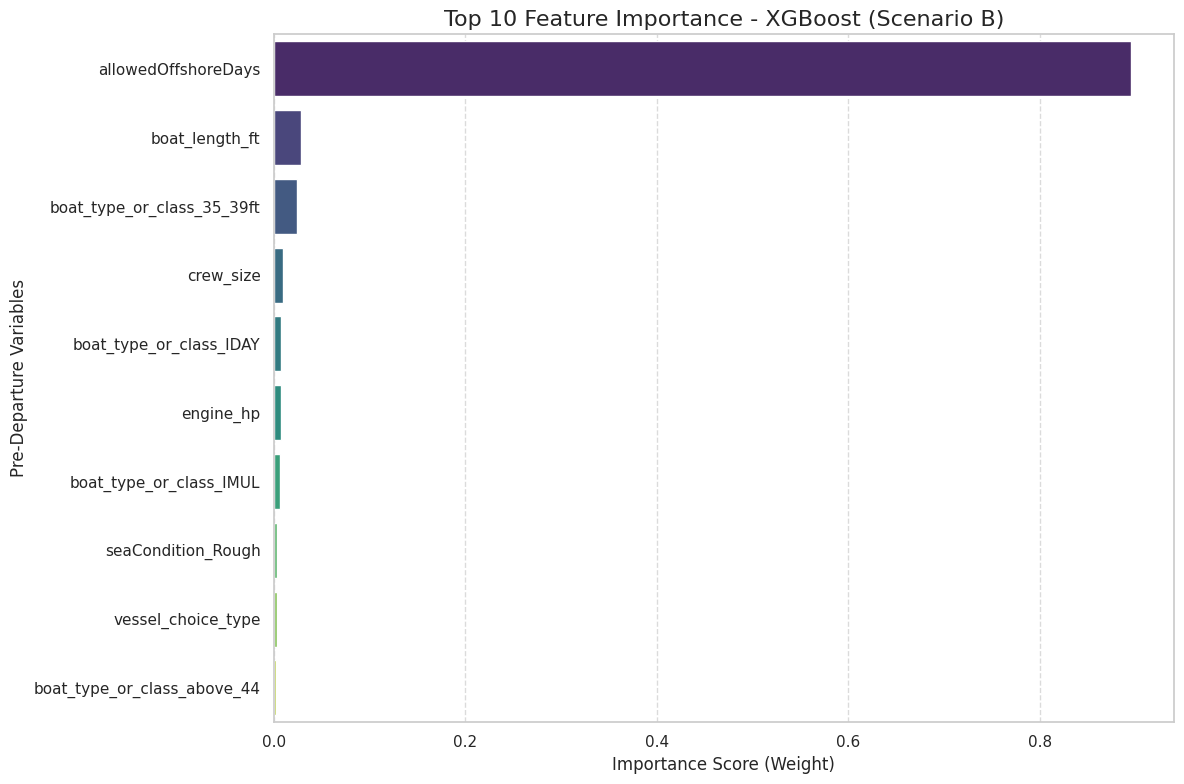

--- Detailed Feature Importance Scores ---
                            Feature  Importance
                allowedOffshoreDays    0.895048
                     boat_length_ft    0.028128
         boat_type_or_class_35_39ft    0.024186
                          crew_size    0.009165
            boat_type_or_class_IDAY    0.007061
                          engine_hp    0.007056
            boat_type_or_class_IMUL    0.006667
                 seaCondition_Rough    0.003377
                 vessel_choice_type    0.003204
        boat_type_or_class_above_44    0.002624
                        distance_km    0.001554
                            tripAge    0.001112
                             wave_m    0.000951
                           wind_kph    0.000740
            boat_type_or_class_NTRB    0.000507
              seaCondition_Moderate    0.000477
              safetyCategory_unsafe    0.000451
                fishingZone_Zone_10    0.000416
                 fishingZone_Zone_1    0.0003

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select your best model (Assuming XGBoost based on your previous results)
best_model = models["XGBoost"]

# 2. Extract Importance Scores
# For XGBoost/Random Forest, this is built-in
importances = best_model.feature_importances_
feature_names = xTrain_B_enc.columns

# 3. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Top 10 Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')

plt.title('Top 10 Feature Importance - XGBoost (Scenario B)', fontsize=16)
plt.xlabel('Importance Score (Weight)', fontsize=12)
plt.ylabel('Pre-Departure Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Print the raw scores for your report appendix
print("--- Detailed Feature Importance Scores ---")
print(feature_importance_df.to_string(index=False))

####Tax calculation

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Reconstruct temporary dataframe for grouping
# We use your requested objects: xTrainObj1 and yTrainObj1
analysis_df = xTrainObj1.copy()
analysis_df['total_cost_LKR'] = yTrainObj1

# 2. Weather Tax (Calm vs Rough)
# Grouping by seaCondition to find the median cost jump
weather_medians = analysis_df.groupby('seaCondition')['total_cost_LKR'].median()

# Dynamic calculation: Comparing the most expensive condition to the cheapest
weather_tax = ((weather_medians.max() - weather_medians.min()) / weather_medians.min()) * 100

# 3. Zone Tax (Cheapest vs Most Expensive Fishing Zone)
# Assuming 'fishingZone' is the column name; if not, this section will skip
if 'fishingZone' in analysis_df.columns:
    zone_medians = analysis_df.groupby('fishingZone')['total_cost_LKR'].median().sort_values()
    zone_tax = ((zone_medians.iloc[-1] - zone_medians.iloc[0]) / zone_medians.iloc[0]) * 100
else:
    zone_tax = 0.0

# 4. Labor Tax (Per Additional Crew Member)
# Linear Regression to find how much 1 extra person adds to the total cost
model_crew = LinearRegression().fit(xTrainObj1[['crew_size']], yTrainObj1)
avg_cost = yTrainObj1.mean()
labor_tax_per_person = (model_crew.coef_[0] / avg_cost) * 100

# 5. Create the Summary Table
dashboard_data = {
    "Operational Variable": ["Sea Condition", "Fishing Zone", "Crew Size"],
    "Financial Metric": ["Weather Tax (Max Variance)", "Zone Tax (Max Variance)", "Labor Tax (Per Extra Person)"],
    "Cost Increase (%)": [f"{weather_tax:.2f}%", f"{zone_tax:.2f}%", f"{labor_tax_per_person:.2f}%"]
}

dashboard_df = pd.DataFrame(dashboard_data)

print("--- STRATEGIC COST DASHBOARD FOR SHIP OWNERS ---")
print(f"Calculated from Average Trip Cost: {avg_cost:,.2f} LKR")
display(dashboard_df)

--- STRATEGIC COST DASHBOARD FOR SHIP OWNERS ---
Calculated from Average Trip Cost: 342,364.63 LKR


,Operational Variable,Financial Metric,Cost Increase (%)
0,Sea Condition,Weather Tax (Max Variance),10.55%
1,Fishing Zone,Zone Tax (Max Variance),20.51%
2,Crew Size,Labor Tax (Per Extra Person),31.33%


####Partial dependancy

Generating Partial Dependence Plots... (This may take a moment)


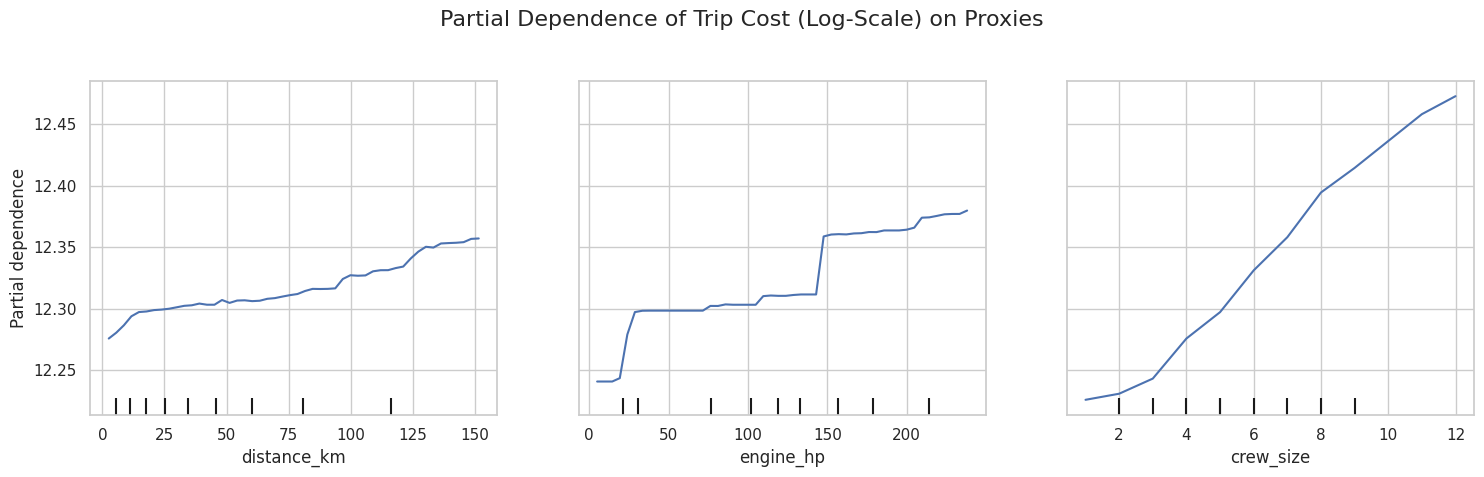

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 1. Select the features you want to analyze
# We pick the most likely cost drivers for your fishing trips
features_to_plot = ['distance_km', 'engine_hp', 'crew_size']

# 2. Setup the Plot
# We use the XGBoost model as it's your top performer
fig, ax = plt.subplots(figsize=(15, 5))

print("Generating Partial Dependence Plots... (This may take a moment)")
display = PartialDependenceDisplay.from_estimator(
    models["XGBoost"],
    xTrain_B_enc,
    features=features_to_plot,
    ax=ax,
    grid_resolution=50
)

# 3. Formatting
plt.suptitle('Partial Dependence of Trip Cost (Log-Scale) on Proxies', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##New model individual project

In [ ]:
import numpy as np

def calculate_vessel_breakeven(model, input_features, market_price_per_kg):
    """
    Individual Project Component: Financial Optimization
    ---------------------------------------------------
    model: Your final log-transformed regression model
    input_features: A 2D array/DataFrame of features (e.g., tripAge, seaCondition, etc.)
    market_price_per_kg: The current market rate for fish in LKR
    """

    # 1. Predict Log Cost
    log_cost = model.predict(input_features)

    # 2. Inverse Transform (Back to actual LKR)
    # Note: Use np.expm1() if you used log1p during training,
    # otherwise use np.exp()
    predicted_actual_cost = np.exp(log_cost)[0]

    # 3. Calculate Break-Even Weight (Cost / Price)
    if market_price_per_kg > 0:
        breakeven_weight = predicted_actual_cost / market_price_per_kg
    else:
        breakeven_weight = np.nan

    return predicted_actual_cost, breakeven_weight

In [ ]:
# --- INDIVIDUAL PROJECT: SIMULATION ---

# 1. Define a hypothetical future trip (using your model's features)
# Replace these with the actual column values from your X_test
example_trip = xTest_B_enc.iloc[0:1]  # Taking one sample trip from your test set

# 2. Define the 'Market Price' (The new variable for your individual part)
current_market_price = 1200 # LKR per kg (e.g., for Yellowfin Tuna)

# 3. Run the optimization
est_cost, target_weight = calculate_vessel_breakeven(models['XGBoost'], example_trip, current_market_price)

print(f"--- Individual Project: Economic Analysis ---")
print(f"Predicted Trip Cost: LKR {est_cost:,.2f}")
print(f"Current Market Price: LKR {current_market_price}/kg")
print(f"Required Catch to Break-Even: {target_weight:.2f} kg")

--- Individual Project: Economic Analysis ---
Predicted Trip Cost: LKR 155,290.16
Current Market Price: LKR 1200/kg
Required Catch to Break-Even: 129.41 kg


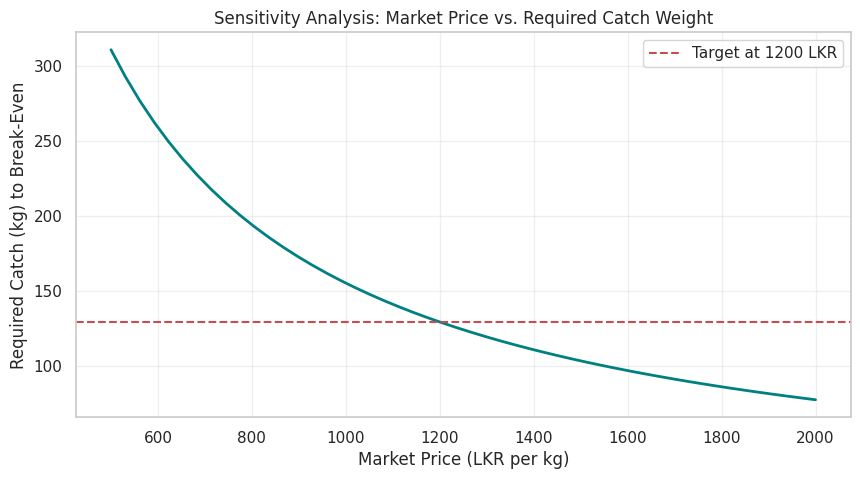

In [ ]:
import matplotlib.pyplot as plt

# Simulate a range of market prices (e.g., 500 LKR to 2000 LKR)
prices = np.linspace(500, 2000, 50)
weights = [est_cost / p for p in prices]

plt.figure(figsize=(10, 5))
plt.plot(prices, weights, color='teal', linewidth=2)
plt.axhline(y=target_weight, color='r', linestyle='--', label=f'Target at {current_market_price} LKR')
plt.title("Sensitivity Analysis: Market Price vs. Required Catch Weight")
plt.xlabel("Market Price (LKR per kg)")
plt.ylabel("Required Catch (kg) to Break-Even")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def individual_breakeven_analysis(model, input_features, market_price):
    """
    Individual Project Logic:
    1. Predicts Log(Cost)
    2. Converts to Actual LKR
    3. Calculates required catch weight (Optimization)
    """
    # Predict using the final group model
    log_pred = model.predict(input_features)

    # Back-transformation (Reverse Log)
    actual_cost = np.exp(log_pred)[0]

    # Calculate Weight: Cost = Weight * Price -> Weight = Cost / Price
    required_weight = actual_cost / market_price

    return actual_cost, required_weight

# --- Execution Example ---
# Replace 'final_rf_model' with your actual model variable name
# Replace 'X_test.iloc[0:1]' with a specific trip's data
current_price_lkr = 1100  # User-defined market price per kg
predicted_total_cost, target_kg = individual_breakeven_analysis(models['XGBoost'], xTest_B_enc.iloc[0:1], current_price_lkr)

print(f"Individual Model Result:")
print(f"Predicted Trip Cost: LKR {predicted_total_cost:,.2f}")
print(f"Break-Even Catch needed at LKR {current_price_lkr}/kg: {target_kg:.2f} kg")

Individual Model Result:
Predicted Trip Cost: LKR 155,290.16
Break-Even Catch needed at LKR 1100/kg: 141.17 kg


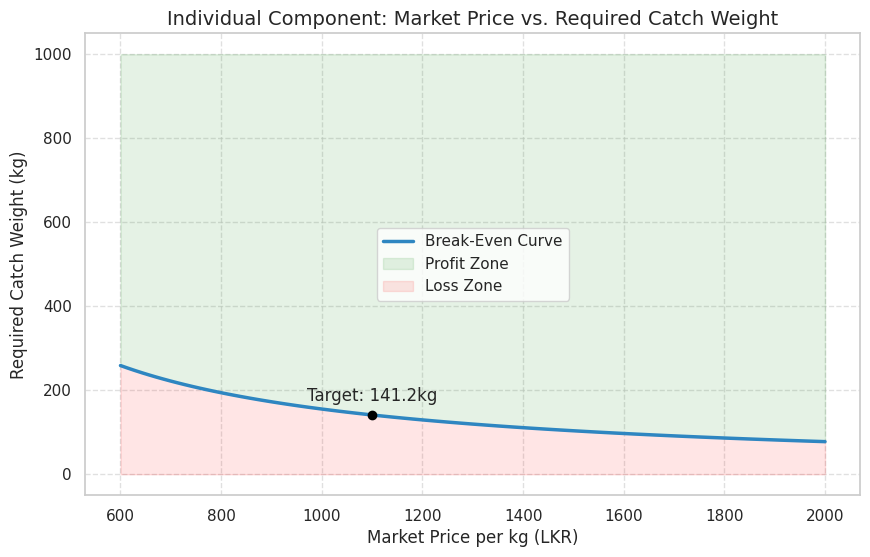

In [ ]:
# Simulation: How the Target Catch changes as Market Price fluctuates
price_range = np.linspace(600, 2000, 100)
required_weights = [predicted_total_cost / p for p in price_range]

plt.figure(figsize=(10, 6))
plt.plot(price_range, required_weights, color='#2E86C1', linewidth=2.5, label='Break-Even Curve')
plt.fill_between(price_range, required_weights, 1000, color='green', alpha=0.1, label='Profit Zone')
plt.fill_between(price_range, 0, required_weights, color='red', alpha=0.1, label='Loss Zone')

# Mark current scenario
plt.scatter(current_price_lkr, target_kg, color='black', zorder=5)
plt.annotate(f'Target: {target_kg:.1f}kg', (current_price_lkr, target_kg), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Individual Component: Market Price vs. Required Catch Weight", fontsize=14)
plt.xlabel("Market Price per kg (LKR)", fontsize=12)
plt.ylabel("Required Catch Weight (kg)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()